In [6]:
import importlib
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
import src.meta_processing as mp
import pandas as pd

gene_expr = pd.read_csv("../data/processed/gene_expression.csv",index_col=0,header=0)
meta = pd.read_csv("../data/processed/metadata.csv", usecols=["id", "WHO grade","Primary/Recurrent"])
importlib.reload(mp)

#Total
typeIII = mp.typeIII
typeIV = mp.typeIV

#Primary and recurrent
III_primary = mp.III_primary
III_recurrent = (mp.III_recurrent)
IV_primary = (mp.IV_primary)
IV_recurrent = (mp.IV_recurrent)

#III sub
III_prim_PN = (mp.III_prim_PN)
III_prim_Mes = (mp.III_prim_Mes)
III_prim_Prolif = (mp.III_prim_Prolif)

III_rec_PN = (mp.III_rec_PN)
III_rec_Mes = (mp.III_rec_Mes)
III_rec_Prolif = (mp.III_rec_Prolif)


#IV sub
IV_prim_PN = (mp.IV_prim_PN)
IV_prim_Mes = (mp.IV_prim_Mes)
IV_prim_Prolif = (mp.IV_prim_Prolif)

IV_rec_PN = (mp.IV_rec_PN)
IV_rec_Mes = (mp.IV_rec_Mes)
IV_prec_Prolif = (mp.IV_rec_Prolif)
meta

Number of primary type III samples: 21
Number of recurrent type III samples: 3
Number of primary type IV samples: 56
Number of recurrent type IV samples: 20


PRIMARY III
PN: 20
Mes: 1
Prolif: 0


RECURRENT III
PN: 2
Mes: 1
Prolif: 0


PRIMARY IV
PN: 10
Mes: 22
Prolif: 24


RECURRENT IV
PN: 5
Mes: 11
Prolif: 4


,id,WHO grade,Primary/Recurrent
0,3744,IV with necrosis,primary
1,3745,IV with necrosis,primary
2,3746,IV with necrosis,primary
3,3747,IV with necrosis,primary
4,3748,IV with necrosis,primary
...,...,...,...
95,4793,III,primary
96,5063,III,primary
97,5070,III,primary
98,9907,IV with necrosis,primary


In [7]:
for gene in gene_expr.index:
    print(gene)

A1BG
A1BG-AS1
A1CF
A2M
A2MP1
A4GALT
A4GNT
AA06
AAAS
AACS
AADAC
AADACL2
AADAT
AAED1
AAGAB
AAK1
AAMDC
AAMP
AANAT
AAR2
AARS
AARS2
AARSD1
AASDH
AASDHPPT
AASS
AATF
AATK
AB074162
AB488780
ABAT
ABCA1
ABCA11P
ABCA12
ABCA17P
ABCA2
ABCA3
ABCA4
ABCA5
ABCA6
ABCA7
ABCA8
ABCA9
ABCB1
ABCB10
ABCB11
ABCB4
ABCB5
ABCB6
ABCB7
ABCB8
ABCB9
ABCC1
ABCC10
ABCC11
ABCC13
ABCC2
ABCC3
ABCC4
ABCC5
ABCC6
ABCC6P1
ABCC6P2
ABCC8
ABCC9
ABCD1
ABCD1P2
ABCD2
ABCD3
ABCD4
ABCE1
ABCF1
ABCF2
ABCF3
ABCG1
ABCG2
ABCG4
ABCG5
ABCG8
ABHD1
ABHD10
ABHD11
ABHD12
ABHD12B
ABHD13
ABHD14A
ABHD14A-ACY1
ABHD14B
ABHD15
ABHD16A
ABHD16B
ABHD17A
ABHD17B
ABHD17C
ABHD2
ABHD3
ABHD4
ABHD5
ABHD6
ABHD8
ABI1
ABI2
ABI3
ABI3BP
ABL1
ABL2
ABLIM1
ABLIM2
ABLIM3
ABO
ABR
ABRACL
ABT1
ABTB1
ABTB2
AC000111.3
AC002059.10
AC002310.7
AC003973.4
AC003989.4
AC004490.1
AC004692.5
AC004941.5
AC005162.4
AC005256.1
AC005306.3
AC005498.3
AC005523.2
AC005523.3
AC005592.3
AC005606.14
AC005754.7
AC005838.2
AC006026.13
AC006129.2
AC006538.1
AC007292.3
AC007362.3
AC007364.1
AC0

# Perform PCA for III and IV

In [8]:
# Cell 1 — prepare labels and align with expression matrix
labels = (
    meta.set_index("id")["WHO grade"]
    .astype(str)
    .str.extract(r"\b(III|IV)\b", expand=False)
)
labels.index = labels.index.astype(str)

X = gene_expr.T.copy()
X.index = X.index.astype(str)

# keep only shared sample IDs and drop missing labels
common_ids = X.index.intersection(labels.index)
X = X.loc[common_ids]
labels = labels.loc[common_ids]
keep = labels.notna()
X = X.loc[keep]
labels = labels.loc[keep]

print("X shape:", X.shape)
print("labels shape:", labels.shape)
print("aligned:", (X.index == labels.index).all())
print(labels.value_counts())

X shape: (100, 21290)
labels shape: (100,)
aligned: True
WHO grade
IV     76
III    24
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# PCA scatter with blue/red for III/IV
color_map = {"III": "blue", "IV": "red"}


Explained variance ratio: [0.09251799 0.06970306]


# Note: No control, just relative to each other

# Volcano plot

In [17]:
# choose how many top genes to show
top_n = 10

# Volcano plot for log2-normalized X (no log ratio needed)
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind


# optional FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    _have_multipletests = True
except Exception:
    _have_multipletests = False

groupA, groupB = "III", "IV"
idxA = (labels == groupA)
idxB = (labels == groupB)

X_A = X.loc[idxA]
X_B = X.loc[idxB]

# log2 fold-change as difference of means (since X is log2)
meanA = X_A.mean(axis=0)
meanB = X_B.mean(axis=0)
log2fc = meanB - meanA

# gene-wise t-test (Welch)
pvals = X.apply(lambda col: ttest_ind(col[idxB], col[idxA], equal_var=False, nan_policy="omit").pvalue, axis=0)

# adjust p-values (Benjamini-Hochberg) if available
if _have_multipletests:
    _, p_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
    p_adj = pd.Series(p_adj, index=pvals.index)
else:
    p_adj = pvals.copy()

neg_log10_p = -np.log10(p_adj + 1e-300)

volcano = pd.DataFrame({
    "log2FC": log2fc,
    "pval": pvals,
    "p_adj": p_adj,
    "neg_log10_p": neg_log10_p
})


# thresholds
fc_thresh = 1.0
p_thresh = 0.05
sig_mask = (volcano["p_adj"] < p_thresh) & (volcano["log2FC"].abs() >= fc_thresh)

# colors: significant down = green, significant up = blue, non-significant = lightgray
colors = np.where(sig_mask, np.where(volcano["log2FC"] < 0, "green", "blue"), "lightgray")


# annotate top significant hits only
top_hits = volcano.loc[sig_mask].sort_values("p_adj").head(top_n)




In [18]:

import numpy as np



# ensure `volcano`, `X`, `labels` exist and are aligned
if "volcano" not in globals():
    raise RuntimeError("`volcano` not found — run the volcano cell first")

# pick only genes that meet both thresholds, then top by adjusted p-value
pcol = "p_adj" if "p_adj" in volcano.columns else "pval"
sig_genes = volcano.loc[sig_mask]
if sig_genes.empty:
    raise RuntimeError("No genes meet the thresholds. Lower thresholds or check data.")
top_genes = sig_genes.sort_values(pcol).index[:top_n].tolist()

# Boxplot
labels.name = "WHO"
df_bp = X[top_genes].join(labels).reset_index().melt(id_vars=["index", "WHO"],
                                                     var_name="gene",
                                                     value_name="expr")


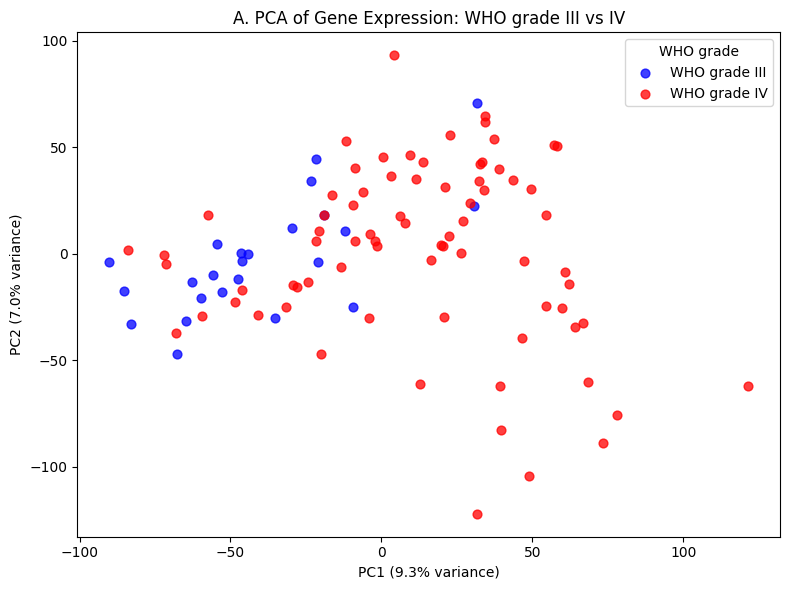

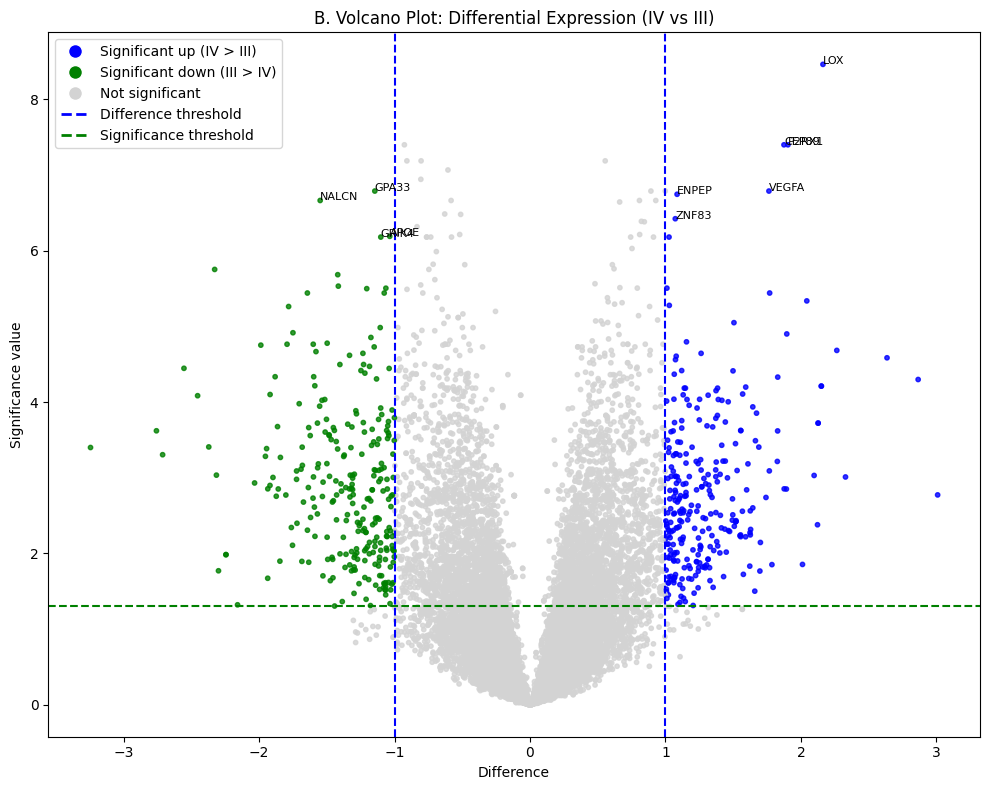

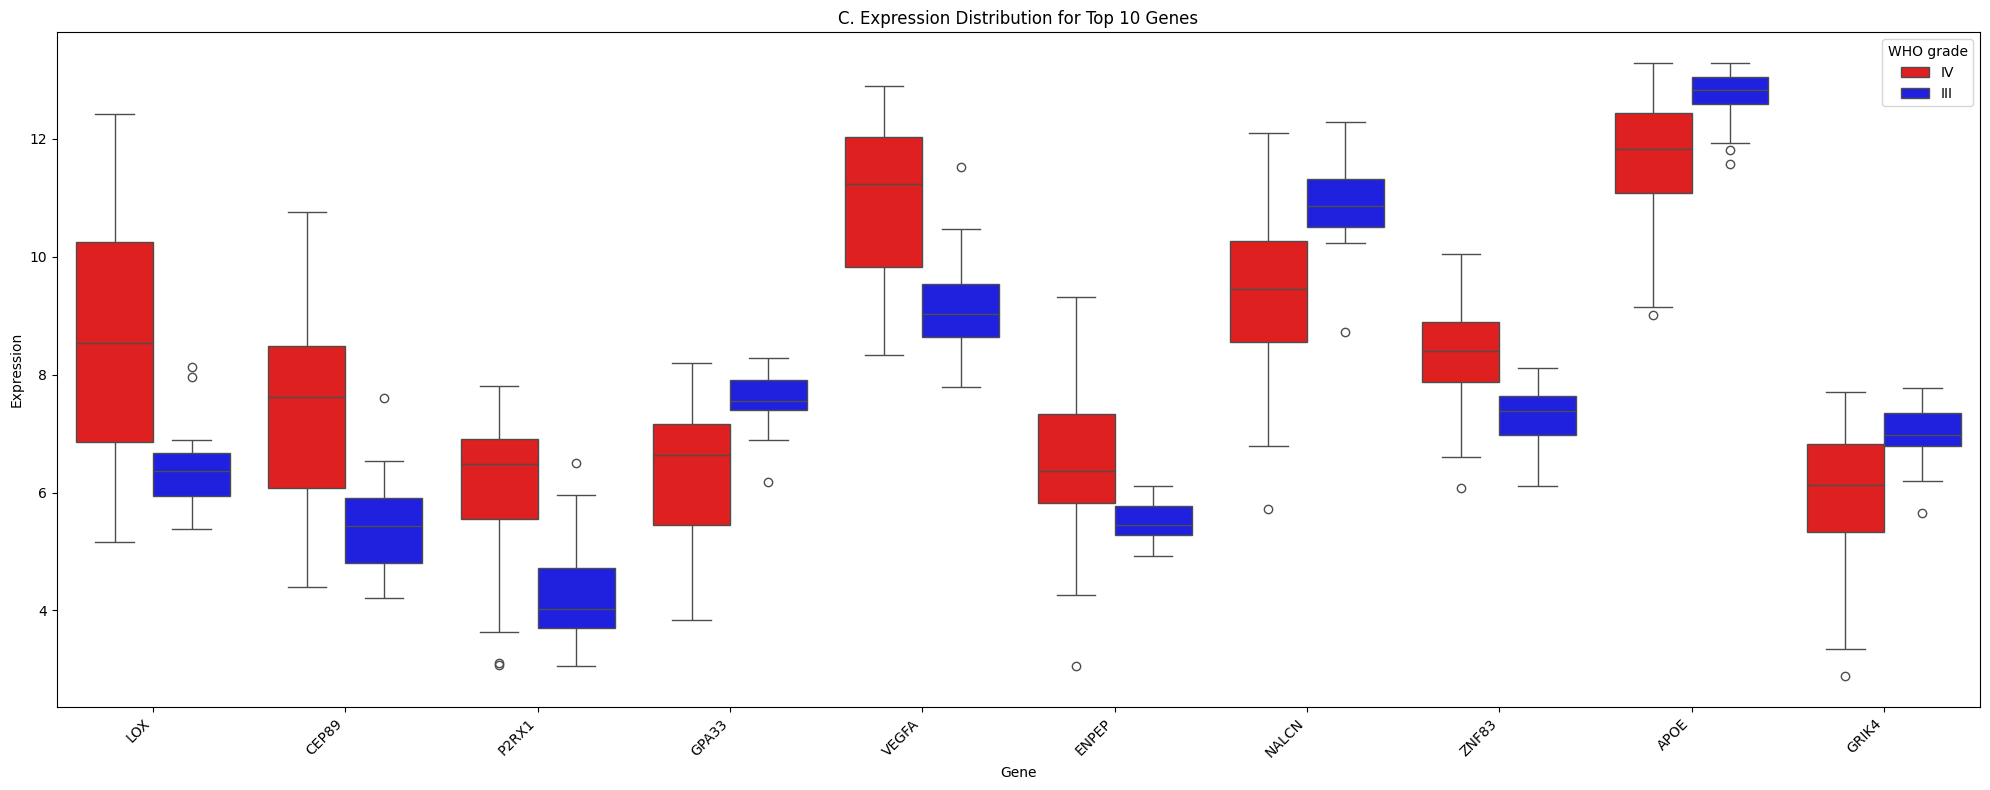

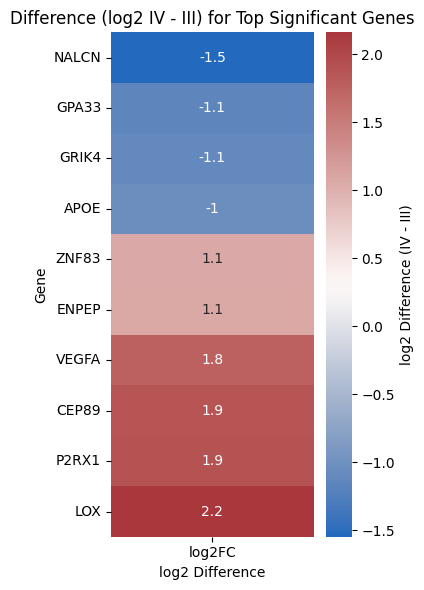

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
# --- PCA plot 
plt.figure(figsize=(8,6))
for t in sorted(labels.unique()):
    mask = (labels == t).to_numpy()
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f"WHO grade {t}",
        color=color_map.get(t, "gray"),
        alpha=0.75, s=40
    )
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("A. PCA of Gene Expression: WHO grade III vs IV")
plt.legend(title="WHO grade", loc="best", frameon=True)
plt.tight_layout()
plt.show()

# --- Volcano plot 
plt.figure(figsize=(10,8))
colors = np.where(sig_mask, np.where(volcano["log2FC"] < 0, "green", "blue"), "lightgray")
plt.scatter(
    volcano["log2FC"], volcano["neg_log10_p"],
    c=colors, s=10, alpha=0.8,
    label="Genes"
)
plt.axvline(fc_thresh, color="blue", linestyle="--", label="Difference threshold")
plt.axvline(-fc_thresh, color="blue", linestyle="--")
plt.axhline(-np.log10(p_thresh), color="green", linestyle="--", label="Significance threshold")
plt.xlabel("Difference")
plt.ylabel("Significance value")
plt.title("B. Volcano Plot: Differential Expression (IV vs III)")
# Custom legend for color meaning
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Significant up (IV > III)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Significant down (III > IV)', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Not significant', markerfacecolor='lightgray', markersize=10),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='Difference threshold'),
    Line2D([0], [0], color='green', lw=2, linestyle='--', label='Significance threshold')
]
plt.legend(handles=legend_elements, loc="upper left", frameon=True)
# Annotate top significant hits only
top_hits = volcano.loc[sig_mask].sort_values("p_adj").head(top_n)
for gene, row in top_hits.iterrows():
    plt.text(row["log2FC"], row["neg_log10_p"], gene, fontsize=8)
plt.tight_layout()
plt.show()

# --- Boxplot
plt.figure(figsize=(max(20, len(top_genes)*0.5), 8))
sns.boxplot(
    x="gene", y="expr", hue="WHO", data=df_bp, order=top_genes,
    palette={"III": "blue", "IV": "red"}
    )
plt.xticks(rotation=45, ha="right")
plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title(f"C. Expression Distribution for Top {len(top_genes)} Genes")
plt.legend(title="WHO grade", loc="best", frameon=True)
plt.tight_layout()
plt.show()

# Order genes by log2FC for better visualization (optional)
ordered_genes = volcano.loc[top_genes].sort_values("log2FC").index

# Create a DataFrame: genes as rows, one column for log2FC
heatmap_fc = pd.DataFrame({'log2FC': log2fc[ordered_genes]}, index=ordered_genes)

plt.figure(figsize=(4, max(6, len(top_genes) * 0.25)))
sns.heatmap(
    heatmap_fc,
    cmap="vlag",
    annot=True,
    cbar_kws={'label': 'log2 Difference (IV - III)'}
)
plt.title("Difference (log2 IV - III) for Top Significant Genes")
plt.ylabel("Gene")
plt.xlabel("log2 Difference")
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

test = pd.read_csv('../data/processed/02CPTAC_C_GBM_W_PNNL_20210121_B1S2_f20.csv')
print(test.shape)
print(test.head())

(21968352, 4)
                                   ScanNumber  RetentionTime         m/z  \
0  controllerType=0 controllerNumber=1 scan=1       0.000451  350.863434   
1  controllerType=0 controllerNumber=1 scan=1       0.000451  350.914337   
2  controllerType=0 controllerNumber=1 scan=1       0.000451  352.870422   
3  controllerType=0 controllerNumber=1 scan=1       0.000451  354.857574   
4  controllerType=0 controllerNumber=1 scan=1       0.000451  354.873688   

   Intensity  
0   8469.058  
1   4706.554  
2   4561.854  
3   6059.755  
4  21475.440  


      Peptide Charge                                Mods    MinFDR  \
0    SSSGMGGR      2  [0:+229.163;[0:+229.163,M5:+15.995  0.000316   
1  SHGASCATQR      3              [0:+229.163,C6:+57.021  0.000000   
2   CHAANPNGR    2;3              [0:+229.163,C1:+57.021  0.000000   
3     SAHQVAR      2                         [0:+229.163  0.001458   
4   HSEAATAQR    2;3                         [0:+229.163  0.000000   

   SpectralCount  AmbigSpectralCount  \
0             51                   0   
1             28                   0   
2            353                   0   
3             71                   0   
4            135                   0   

                                              Sample  \
0  01CPTAC_C_GBM_Proteome_PNNL_20210121;02CPTAC_C...   
1  01CPTAC_C_GBM_Proteome_PNNL_20210121;02CPTAC_C...   
2  01CPTAC_C_GBM_Proteome_PNNL_20210121;02CPTAC_C...   
3  01CPTAC_C_GBM_Proteome_PNNL_20210121;02CPTAC_C...   
4  01CPTAC_C_GBM_Proteome_PNNL_20210121;02CPTAC_C...   

 